A notebook for getting familiar with making light curves from astronomical images

In [11]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from photutils.detection import DAOStarFinder

Load data from Las Cumbres (redirect to wherever this folder is for you)

In [9]:
data_folder = '/Users/layden/Library/CloudStorage/Box-Box/Scientific CMOS - MKI ONLY (might contain EAR; ITAR)/Random_Telegraph_Noise/quaoar_ogg_0m4b/quaoar_test_dataset'
frame_shape = fits.open(os.path.join(data_folder, os.listdir(data_folder)[0]))[0].data.shape
# Create an empty stack to hold 1000 frames
num_frames = 1000
science_stack = np.zeros((num_frames, *frame_shape))
files = sorted([f for f in os.listdir(data_folder) if f.endswith('.fits')])
for i, file in enumerate(files):
    if i >= num_frames:
        break
    frame_data = fits.open(os.path.join(data_folder, file))[0].data
    science_stack[i] = frame_data
science_stack -= 441 # Subtract bias level. A more sophisticated method would subtract an average bias frame.

Identify stars and visualize them on an averaged frame

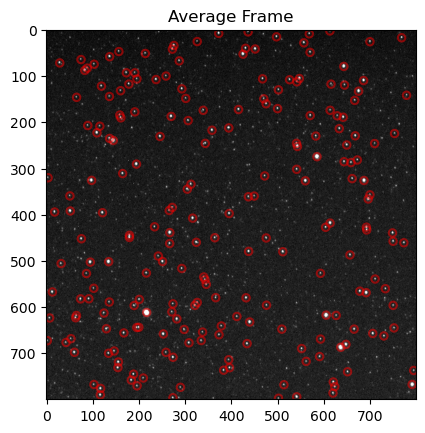

In [18]:
avg_frame = np.mean(science_stack, axis=0)
# Defining a function to identify sources using DAOStarFinder
# This function basically finds any parts of the image (with size set by fwhm) that have
# an average brightness above a certain threshold.
daofinder = DAOStarFinder(threshold=20., fwhm=5.)
sources = daofinder(avg_frame)
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
# Define apertures around the identified sources.
aper_radius = 8
apertures = CircularAperture(positions, r=aper_radius)
# Define annuli around each source. We measure the median flux in these annuli
# and subtract it from the flux in the aperture to remove background light.
annuli = CircularAnnulus(positions, r_in=aper_radius+2, r_out=aper_radius+10)
plt.imshow(avg_frame, cmap='gray', vmin=0, vmax=20)
apertures.plot(color='red', lw=1.5, alpha=0.5)
plt.title('Average Frame')
plt.show()

Now we'll start making light curves. We want to measure the background-subtracted brightness of every source in every frame.

In [20]:
light_curves = np.zeros((len(sources), num_frames))
# Creates "masks" for each annulus, which say whether a given pixel is inside or outside the annulus.
annulus_masks = annuli.to_mask()
for i in range(num_frames):
    print(f'Processing frame {i+1}/{num_frames}')
    frame = science_stack[i]
    # Prepare empty array to hold the median background values for each source
    bkg_medians = np.zeros(len(sources))
    for j, mask in enumerate(annulus_masks):
        annulus_data = mask.multiply(frame)
        median_bkg = np.median(annulus_data)
        bkg_medians[j] = median_bkg
    # A pre-defined function in photutils that calculates the total flux in each aperture.
    phot_table = aperture_photometry(frame, apertures)
    # Subtract the background median from the aperture sum to get the net flux.
    fluxes = phot_table['aperture_sum'] - bkg_medians * apertures.area
    light_curves[:, i] = fluxes

Processing frame 1/1000
Processing frame 2/1000
Processing frame 3/1000
Processing frame 4/1000
Processing frame 5/1000
Processing frame 6/1000
Processing frame 7/1000
Processing frame 8/1000
Processing frame 9/1000
Processing frame 10/1000
Processing frame 11/1000
Processing frame 12/1000
Processing frame 13/1000
Processing frame 14/1000
Processing frame 15/1000
Processing frame 16/1000
Processing frame 17/1000
Processing frame 18/1000
Processing frame 19/1000
Processing frame 20/1000
Processing frame 21/1000
Processing frame 22/1000
Processing frame 23/1000
Processing frame 24/1000
Processing frame 25/1000
Processing frame 26/1000
Processing frame 27/1000
Processing frame 28/1000
Processing frame 29/1000
Processing frame 30/1000
Processing frame 31/1000
Processing frame 32/1000
Processing frame 33/1000
Processing frame 34/1000
Processing frame 35/1000
Processing frame 36/1000
Processing frame 37/1000
Processing frame 38/1000
Processing frame 39/1000
Processing frame 40/1000
Processin

Plot a few light curves

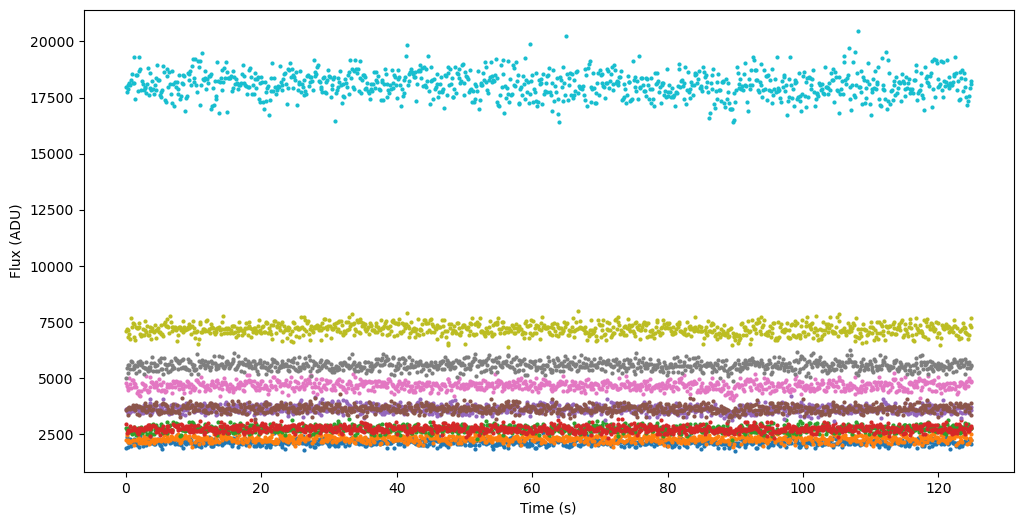

In [26]:
# Get indices of the 10 brightest sources
times = np.arange(num_frames) * 0.125 # Exposure time here is 0.125 seconds
brightest_indices = np.argsort(np.sum(light_curves, axis=1))[-10:]
plt.figure(figsize=(12, 6))
for idx in brightest_indices:
    plt.plot(times, light_curves[idx], 'o', markersize=2, label=f'Source {idx}')
plt.xlabel('Time (s)')
plt.ylabel('Flux (ADU)')
plt.show()


Measure the noise in each light curve and see how well it agrees with the prediction

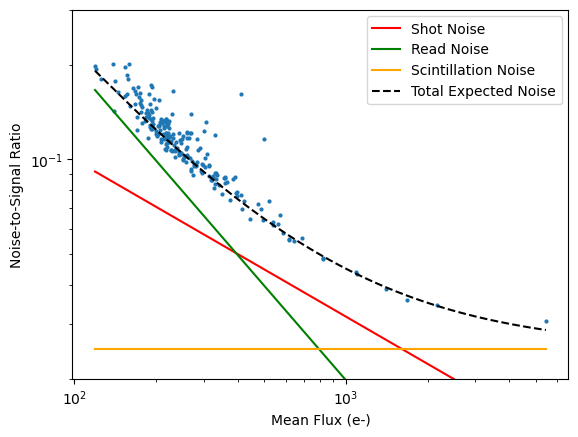

In [51]:
gain = 3.32 # ADU/e-
light_curves_electrons = light_curves / gain
mean_vals = np.mean(light_curves_electrons, axis=1)
std_vals = np.std(light_curves_electrons, axis=1)
# Calculate noise-to-signal ratio
nsr_vals = std_vals / mean_vals
# Calculate the expected contributions from shot noise, read noise, and scintillation noise
x_vals = np.linspace(np.min(mean_vals), np.max(mean_vals), 100)
nsr_shot_noise = 1 / np.sqrt(x_vals)
num_pix = apertures.area
nsr_read_noise = 1.4 * np.sqrt(num_pix) / x_vals
# Scintillation noise is a constant noise source caused by atmospheric turbulence.
# It basically acts as a floor on how low the NSR can go.
nsr_scintillation = 0.025 * np.ones_like(x_vals)
tot_nsr = np.sqrt(nsr_shot_noise**2 + nsr_read_noise**2 + nsr_scintillation**2)
plt.plot(mean_vals, nsr_vals, 'o', markersize=2)
plt.plot(x_vals, nsr_shot_noise, label='Shot Noise', color='red')
plt.plot(x_vals, nsr_read_noise, label='Read Noise', color='green')
plt.plot(x_vals, nsr_scintillation, label='Scintillation Noise', color='orange')
plt.plot(x_vals, tot_nsr, label='Total Expected Noise', color='black', linestyle='--')
plt.ylim(0.02, 0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mean Flux (e-)')
plt.ylabel('Noise-to-Signal Ratio')
plt.legend()
plt.show()

A few things it would be useful to learn/practice:
- What is the FWHM of the stars in the image? This sets how big of an aperture we should use (typically ~2-3x the FWHM). You could do this by increasing the aperture radius until the flux stops increasing or by using some pre-defined function like https://photutils.readthedocs.io/en/latest/api/photutils.psf.fit_fwhm.html
- How well do the stars stay in place over the set of images? You might use daofind on some of the frames spaced throughout the full ~15000 frames in 'Random_Telegraph_Noise/quaoar_ogg_0m4b/quaoar_ogg_0m4b_exo_0125' to see if there is a long-term drift in the telescope pointing. If the stars move appreciably, then we need to account for that when making light curves.